In [ ]:
import re
import numpy as np
import emcee
import matplotlib.pyplot as plt
import corner
import scipy.integrate

In [2]:
def load_CC(filename):

    z_list, H_list, sH_list = [], [], []
    pattern = re.compile(
        r"\$([\d\.]+)\$.*?\$([\d\.]+)\s*\\pm\s*([\d\.]+)\$"
    )
    
    with open(filename, "r", encoding="utf-8") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                z, H, sH = map(float, match.groups())
                z_list.append(z)
                H_list.append(H)
                sH_list.append(sH)
    
    z = np.array(z_list)
    Hz = np.array(H_list)
    sigma_Hz = np.array(sH_list)
    
    return {
        "z": z,
        "Hz": Hz,
        "sigma_Hz": sigma_Hz,
        "cov": None
    }


In [3]:
data_CC = load_CC("Cosmic_chronometers_data.tex")
data_CC.keys()

dict_keys(['z', 'Hz', 'sigma_Hz', 'cov'])

In [4]:
def load_PPSH0ES(filename):
    with open(filename, 'r') as f:
        header_line = ''
        for line in f:
            if not line.strip().startswith('#'):  # skip comments
                header_line = line.strip()
                break
        #  Header contains column names
        column_names = header_line.split()

    data = np.genfromtxt(filename, names=column_names, comments='#', skip_header=1)

    # Relevant columns
    z = data["zHD"]
    mu = data["MU_SH0ES"]
    mu_err = data["MU_SH0ES_ERR_DIAG"]

    RA = data["RA"] if "RA" in data.dtype.names else None
    DEC = data["DEC"] if "DEC" in data.dtype.names else None
    HOST_LOGMASS = data["HOST_LOGMASS"] if "HOST_LOGMASS" in data.dtype.names else None

    data_SN = {
        "z": z,
        "mu": mu,
        "sigma_mu": mu_err,
        "cov": None,       
        "mu0_marg": True,  
        "meta": {
            "RA": RA,
            "DEC": DEC,
            "HOST_LOGMASS": HOST_LOGMASS
        }
    }

    return data_SN


In [5]:
data_SN = load_PPSH0ES("Pantheon+SH0ES.dat.txt")

data_SN.keys()

dict_keys(['z', 'mu', 'sigma_mu', 'cov', 'mu0_marg', 'meta'])

## Flat $ \Lambda CDM $ Model Equations

Below are the fundamental equations that define the key cosmological functions based on the flat $\Lambda\text{CDM}$ model, along with their main parameters: the Hubble Constant ($H_0$) and the Matter Density ($\Omega_m$).


### 1. Hubble Expansion Rate ($H(z)$)

The Universe's expansion rate as a function of redshift ($z$) is modeled as:

$$H(z) = H_0 \sqrt{\Omega_m (1 + z)^3 + (1 - \Omega_m)}$$

* $H(z)$: Hubble rate at redshift $z$.
* $H_0$: Hubble Constant (current value).
* $\Omega_m$: Fractional matter density.
* $(1 - \Omega_m)$: Fractional dark energy density ($\Omega_\Lambda$).


### 2. Luminosity Distance ($d_L$)

The luminosity distance ($d_L$), measured in $\text{Mpc}$, is calculated using the following integral:

$$d_L(z) = (1 + z) \frac{c}{H_0} \int_{0}^{z} \frac{dz'}{\sqrt{\Omega_m (1 + z')^3 + (1 - \Omega_m)}}$$

* $c$: Speed of light.
* $\int_{0}^{z} \dots$: Represents the line-of-sight comoving distance ($D_M$), where the integral is the inverse of the $H_{LCDM}$ function (normalized by $H_0$).


### 3. Distance Modulus ($\mu$)

The distance modulus ($\mu$) converts the luminosity distance to a logarithmic scale:

$$\mu(z) = 5 \log_{10} \left( \frac{d_L(z)}{\text{1 Mpc}} \right) + 25$$

* $\mu(z)$: Distance modulus in magnitude.

These equations allow one to fit the $H_0$ and $\Omega_m$ parameters to Type Ia supernova data.

In [7]:
from cosmology_lcdm import log_posterior_lcdm

ndim = 2                  # H0, Omega_m
nwalkers = 40             
nsteps = 5000

initial = np.array([70, 0.3]) # start walkers around "reasonable/educated values"
pos = initial + 1e-2 * np.random.randn(nwalkers, ndim)

sampler_lcdm = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_lcdm, args=(data_CC, data_SN))

print("Running MCMC...")
sampler_lcdm.run_mcmc(pos, nsteps, progress=True)

print("Done!")

Running MCMC...


100%|██████████| 5000/5000 [00:45<00:00, 109.17it/s]

Done!


In [9]:
burn_in = int(nsteps * 0.2)
samples_lcdm = sampler_lcdm.get_chain(discard=burn_in, flat=True)

H0_mcmc, Om_mcmc = np.percentile(samples_lcdm, [16, 50, 84], axis=0).T

H0_err_up = H0_mcmc[2] - H0_mcmc[1]
H0_err_low = H0_mcmc[1] - H0_mcmc[0]
Om_err_up = Om_mcmc[2] - Om_mcmc[1]
Om_err_low = Om_mcmc[1] - Om_mcmc[0]

print("--------------------------------------")
print(f"H0 = {H0_mcmc[1]:.2f} (+{H0_err_up:.2f} / -{H0_err_low:.2f}) km/s/Mpc")
print(f"Ωm = {Om_mcmc[1]:.3f} (+{Om_err_up:.3f} / -{Om_err_low:.3f})")
print("--------------------------------------")

--------------------------------------
H0 = 73.20 (+0.25 / -0.25) km/s/Mpc
Ωm = 0.324 (+0.016 / -0.016)
--------------------------------------


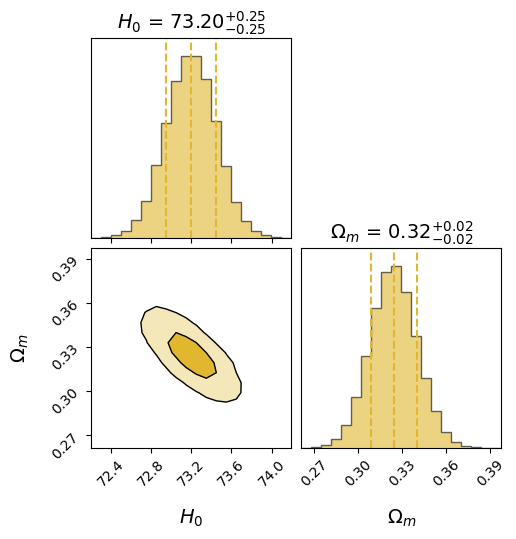

In [ ]:
from cornerplot import plot_cosmo_corner

plot_cosmo_corner(samples_lcdm, labels=[r"$H_0$", r"$\Omega_m$"])

The analysis successfully reproduces the central value $H_0 = 73.20$ km/s/Mpc, confirming the local result from the SH0ES team (Riess et al.).

The resulting error bars ($\pm 0.25$) are significantly smaller than the published ones ($\sim \pm 1.0$). This is because this simplified analysis does not use the full systematic covariance matrix nor does it marginalize over the supernova absolute magnitude ($M_B$).

## Flat $ wCDM $ Model Equations

Below are the fundamental equations that define the key cosmological functions based on the flat $w\text{CDM}$ model, along with their main parameters: the Hubble Constant ($H_0$), the Matter Density ($\Omega_m$), and the Dark Energy Equation of State ($w$).

This model extends $ \Lambda CDM $ by allowing the equation of state $w$ to be a free constant, rather than fixed at $w = -1$.

### 1. Hubble Expansion Rate $H(z)$

The Universe's expansion rate as a function of redshift ($z$) is modeled as:

$$H(z) = H_0 \sqrt{\Omega_m (1 + z)^3 + (1 - \Omega_m) (1 + z)^{3(1 + w)}}$$

* $H(z)$: Hubble rate at redshift $z$.
* $H_0$: Hubble Constant (current value).
* $\Omega_m$: Fractional matter density.
* $(1 - \Omega_m)$: Fractional dark energy density ($\Omega_{DE}$).
* $w$: The equation of state parameter for dark energy.

### 2. Luminosity Distance ($d_L$)

The luminosity distance ($d_L$), measured in $\text{Mpc}$, is calculated using the following integral:

$$d_L(z) = (1 + z) \frac{c}{H_0} \int_{0}^{z} \frac{dz'}{\sqrt{\Omega_m (1 + z')^3 + (1 - \Omega_m) (1 + z')^{3(1 + w)}}}$$

* $c$: Speed of light.
* $\int_{0}^{z} \dots$: Represents the line-of-sight comoving distance ($D_M$).

### 3. Distance Modulus ($\mu$)

The distance modulus ($\mu$) c:

$$\mu(z) = 5 \log_{10} \left( \frac{d_L(z)}{\text{1 Mpc}} \right) + 25$$

* $\mu(z)$: Distance modulus in magnitude.


In [12]:
from cosmology_wcdm import log_posterior_wcdm


ndim = 3  # H0, Omega_m, w
nwalkers = 40 

initial = np.array([70, 0.3, -1.0]) 
pos = initial + 1e-2 * np.random.randn(nwalkers, ndim)

sampler_wcdm = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_wcdm, args=(data_CC, data_SN))

print("Running MCMC (wCDM model)...")
sampler_wcdm.run_mcmc(pos, nsteps, progress=True)
print("Listo!")

Running MCMC (wCDM model)...


100%|██████████| 5000/5000 [00:59<00:00, 83.87it/s]

Listo!


In [13]:
burn_in = int(nsteps * 0.2)
samples_wcdm = sampler_wcdm.get_chain(discard=burn_in, flat=True)

H0_mcmc, Om_mcmc, w_mcmc = np.percentile(samples_wcdm, [16, 50, 84], axis=0).T

H0_err_up = H0_mcmc[2] - H0_mcmc[1]
H0_err_low = H0_mcmc[1] - H0_mcmc[0]
Om_err_up = Om_mcmc[2] - Om_mcmc[1]
Om_err_low = Om_mcmc[1] - Om_mcmc[0]
w_err_up = w_mcmc[2] - w_mcmc[1]
w_err_low = w_mcmc[1] - w_mcmc[0]

print("--------------------------------------")
print(f"H0 = {H0_mcmc[1]:.2f} (+{H0_err_up:.2f} / -{H0_err_low:.2f}) km/s/Mpc")
print(f"Ωm = {Om_mcmc[1]:.3f} (+{Om_err_up:.3f} / -{Om_err_low:.3f})")
print(f"w = {w_mcmc[1]:.3f} (+{w_err_up:.3f} / -{w_err_low:.3f})")
print("--------------------------------------")

--------------------------------------
H0 = 72.84 (+0.30 / -0.29) km/s/Mpc
Ωm = 0.234 (+0.051 / -0.055)
w = -0.791 (+0.089 / -0.098)
--------------------------------------


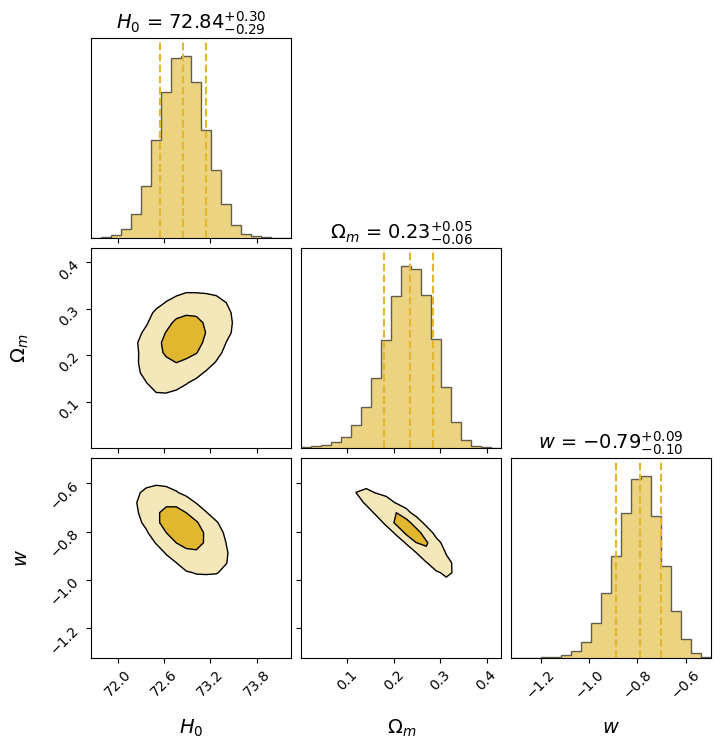

In [14]:
from cornerplot import plot_cosmo_corner

plot_cosmo_corner(samples_wcdm, labels=[r"$H_0$", r"$\Omega_m$", r"$w$"])


### $\omega CDM $  Model Summary

This analysis focuses on constraining the set of parameters: {$H_0$, $\Omega_m$, $w$}.

## MCMC results
| Parameter | Best Fit Value | $1\sigma$ Constraints |
| :---: | :---: | :---: |
| **$H_0$** | $72.84$ km/s/Mpc | $72.84^{+0.30}_{-0.29}$ km/s/Mpc |
| **$\Omega_m$** | $0.23$ | $0.23^{+0.05}_{-0.06}$ |
| **$w$** | $-0.79$ | $-0.79^{+0.09}_{-0.10}$ |

## Interpretation
* **Hubble Constant ($H_0$):** The value is in **excellent agreement** with the local $\Lambda CDM $ measurement of $H_0 = 73.20$ km/s/Mpc, confirming the high expansion rate suggested by the local distance ladder.
* **Dark Energy Equation of State ($w$):** The central value $w = -0.79$ suggests a deviation from the cosmological constant ($\Lambda CDM $)  value of $w=-1$. However, the $w=-1$ value remains within the $2\sigma$ confidence region, indicating that a cosmological constant is still consistent with the data.
* **Correlations:** A strong degeneracy exists between the matter density $\Omega_m$ and the equation of state $w$. To accommodate the distance data, lower values of $\Omega_m$ must be compensated by more negative values of $w$ (and vice-versa).

## Flat CPL Model Equations

Below are the fundamental equations for the CPL (Chevallier-Polarski-Linder) model. This model extends $wCDM$ by allowing the dark energy equation of state, $w$, to evolve with redshift ($z$).

The main parameters are: the Hubble Constant ($H_0$), the Matter Density ($\Omega_m$), the equation of state today ($w_0$), and the evolutionary parameter ($w_a$).

### 1. Dark Energy Equation of State $w(z)$

The CPL model parameterizes the evolution of $w$ as:

$$w(z) = w_0 + w_a \left( \frac{z}{1+z} \right)$$

* $w_0$: The equation of state parameter today (at $z=0$).
* $w_a$: The evolutionary parameter describing how $w$ changes.

### 2. Hubble Expansion Rate ($H(z)$)

This evolving $w(z)$ results in the following expansion rate:

$$H(z) = H_0 \sqrt{\Omega_m (1 + z)^3 + (1 - \Omega_m) (1+z)^{3(1+w_0+w_a)} \exp\left(-\frac{3 w_a z}{1+z}\right)}$$

* $H(z)$: Hubble rate at redshift $z$.
* $H_0$: Hubble Constant (current value).
* $\Omega_m$: Fractional matter density.
* $(1 - \Omega_m)$: Fractional dark energy density ($\Omega_{DE}$).
* $w_0$, $w_a$: The CPL parameters for dark energy.

### 3. Luminosity Distance ($d_L$)

The luminosity distance ($d_L$), measured in $\text{Mpc}$, is calculated by integrating the inverse of the new $H(z)$:

$$d_L(z) = (1 + z) \frac{c}{H_0} \int_{0}^{z} \frac{dz'}{\sqrt{\Omega_m (1 + z')^3 + (1 - \Omega_m) (1+z')^{3(1+w_0+w_a)} \exp\left(-\frac{3 w_a z'}{1+z'}\right)}}$$

* $c$: Speed of light.
* $\int_{0}^{z} \dots$: Represents the line-of-sight comoving distance ($D_M$).

### 4. Distance Modulus ($\mu$)

The distance modulus ($\mu$) definition remains the same:

$$\mu(z) = 5 \log_{10} \left( \frac{d_L(z)}{\text{1 Mpc}} \right) + 25$$

* $\mu(z)$: Distance modulus in magnitude.

In [15]:
from cosmology_cpl import log_posterior_cpl


ndim = 4  # H0, Omega_m, w
nwalkers = 40 


initial = np.array([70, 0.3, -1.0, 0.0 ]) 
pos = initial + 1e-2 * np.random.randn(nwalkers, ndim)

sampler_cpl = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_cpl, args=(data_CC, data_SN))

print("Running MCMC (CPL model)...")
sampler_cpl.run_mcmc(pos, nsteps, progress=True)
print("Listo!")



Running MCMC (CPL model)...


100%|██████████| 5000/5000 [01:01<00:00, 80.88it/s]

Listo!


In [16]:
burn_in = int(nsteps * 0.2)
samples_cpl = sampler_cpl.get_chain(discard=burn_in, flat=True)

H0_mcmc, Om_mcmc, w0_mcmc, wa_mcmc = np.percentile(samples_cpl, [16, 50, 84], axis=0).T

H0_err_up = H0_mcmc[2] - H0_mcmc[1]
H0_err_low = H0_mcmc[1] - H0_mcmc[0]
Om_err_up = Om_mcmc[2] - Om_mcmc[1]
Om_err_low = Om_mcmc[1] - Om_mcmc[0]
w0_err_up = w0_mcmc[2] - w0_mcmc[1]
w0_err_low = w0_mcmc[1] - w0_mcmc[0]
wa_err_up = wa_mcmc[2] - wa_mcmc[1]
wa_err_low = wa_mcmc[1] - wa_mcmc[0]

print("--------------------------------------")
print(f"H0 = {H0_mcmc[1]:.2f} (+{H0_err_up:.2f} / -{H0_err_low:.2f}) km/s/Mpc")
print(f"Ωm = {Om_mcmc[1]:.3f} (+{Om_err_up:.3f} / -{Om_err_low:.3f})")
print(f"w0 = {w0_mcmc[1]:.3f} (+{w0_err_up:.3f} / -{w0_err_low:.3f})")
print(f"wa = {wa_mcmc[1]:.3f} (+{wa_err_up:.3f} / -{wa_err_low:.3f})")
print("--------------------------------------")

--------------------------------------
H0 = 72.82 (+0.34 / -0.34) km/s/Mpc
Ωm = 0.254 (+0.074 / -0.121)
w0 = -0.775 (+0.091 / -0.101)
wa = -0.137 (+0.645 / -1.073)
--------------------------------------


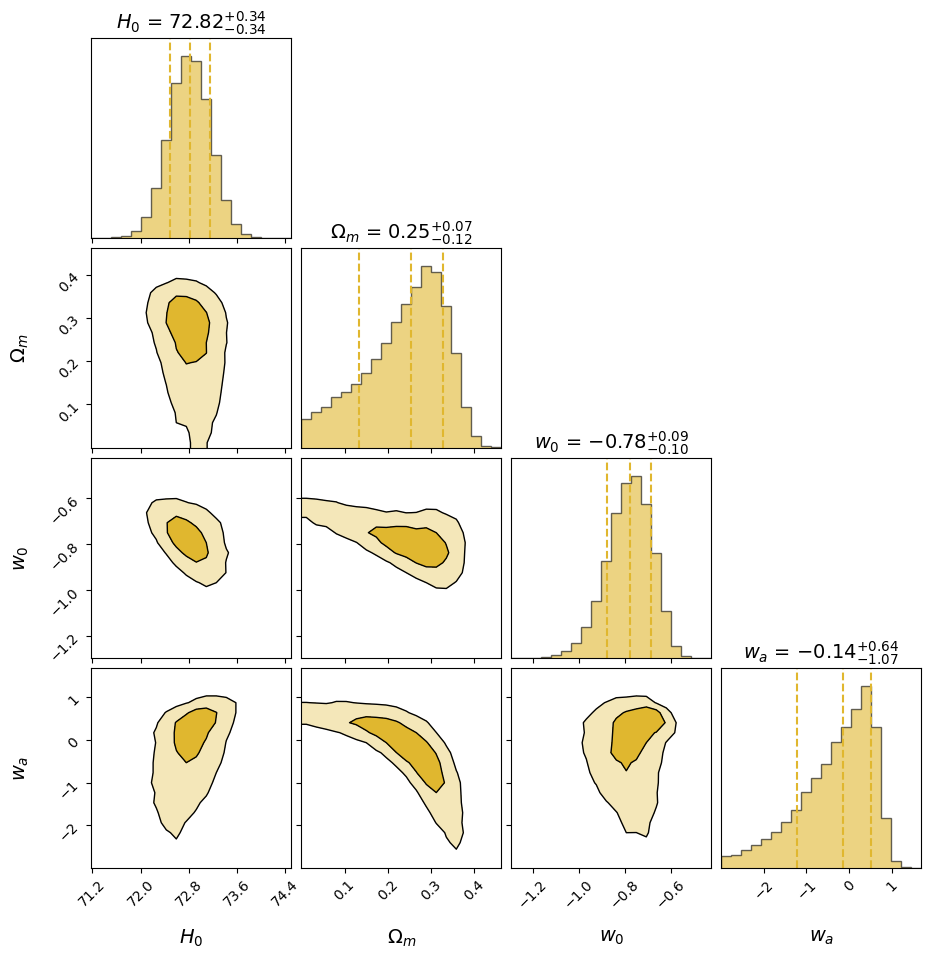

In [17]:
from cornerplot import plot_cosmo_corner

plot_cosmo_corner(samples_cpl, labels=[r"$H_0$", r"$\Omega_m$", r"$w_0$", r"$w_a$"])

## CPL Model Summary
The CPL (Chevallier-Polarski-Linder) model allows for a **time-varying** dark energy equation of state: $w(z) = w_0 + w_a \frac{z}{1+z}$. This analysis constrains the parameter set: {$H_0$, $\Omega_m$, $w_0$, $w_a$}.

## Key Results
| Parameter | Best Fit Value | $1\sigma$ Constraints | Observatios |
| :---: | :---: | :---: | :---: |
| **$H_0$** | $72.82$ km/s/Mpc | $72.82^{+0.34}_{-0.34}$ km/s/Mpc | High-$H_0$ (Consistent with SH0ES) |
| **$\Omega_m$** | $0.25$ | $0.25^{+0.07}_{-0.12}$ | Higher than wCDM, still low |
| **$w_0$** | $-0.78$ | $-0.78^{+0.09}_{-0.10}$ | Consistent with wCDM constant $w$ |
| **$w_a$** | $-0.14$ | $-0.14^{+0.64}_{-1.07}$ | $w_a$ is consistent with zero ($w_a=0$) |

## Interpretation

* **Hubble Constant ($H_0$):** The result of $H_0 = 72.82$ km/s/Mpc is highly consistent with the local SH0ES value ($H_0 \approx 73.20$ km/s/Mpc), further confirming the high local expansion rate.

* **Dark Energy Evolution ($w_a$):** The constraints on the evolution parameter $w_a$ are very weak. The best-fit value of $w_a \approx -0.14$ is well within $1\sigma$ of zero. Therefore, this analysis **finds no significant evidence for dark energy evolution**, suggesting the simpler wCDM model is statistically preferred.

* **Correlations:** The 2D contour for $w_0$ vs. $w_a$ is highly degenerated, a characteristic challenge in constraining the time evolution of dark energy.